# **DEPRECATED** — use `notebooks/dermamnist_full_validation.ipynb` §5–6 and `notebooks/retinamnist_organcmnist_deferral.ipynb` instead.

# Final MSA + Linear Deferral Experiment

Tests whether **sample-specific optimization-history retrieval** (multi-head attention from penultimate representation `h(x)` to frozen V5B memory `M`) improves **selective prediction / human deferral** beyond normalized predictive entropy `H(x)` alone.

## Protocol (frozen)

- **Model:** Frozen ResNet-18 + frozen V5B long-term memory (seeds 42, 123, 456)
- **MSA:** Trained on ID **calibration** only; `h(x)` attends to projected memory tokens `M = {L^(1), L^(2), L^(3)}`
- **Scorers (linear logistic):** `H`, `N` (from `z_N'`), `H+N`
- **Threshold:** Calibrated on calibration for ~20% deferral; **frozen** for DermaMNIST-E external test
- **Primary comparison:** `H` vs `H+N` (not N vs H)
- **Controls:** H-conditioned permutation of `z_N'`

Artifacts → `research/dermamnist_msa_linear_deferral/`

## Configuration

In [1]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import sys


def _find_repo_root(cwd: Path | None = None) -> Path:
    root = Path(cwd or Path.cwd()).resolve()
    if (root / "research").exists():
        return root
    if (root.parent / "research").exists():
        return root.parent
    return root


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from research.common.msa_linear_deferral import MSALinearDeferralConfig

cfg = MSALinearDeferralConfig(
    repo_root=REPO_ROOT,
    source_experiment_dir=REPO_ROOT / "research" / "final_experiment",
    data_dir=REPO_ROOT / "data" / "clinical",
    output_dir=REPO_ROOT / "research" / "dermamnist_msa_linear_deferral",
    seeds=(42, 123, 456),
    n_heads=4,
    d_k=64,
    d_out=128,
    memory_proj_dim=512,
    msa_train_steps=400,
    target_deferral_rate=0.20,
    n_bootstrap=2000,
    show_plots=True,
    save_artifacts=True,
)
cfg = cfg.resolve_paths()
for k, v in asdict(cfg).items():
    print(f"  {k}: {v}")

  repo_root: C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm
  source_experiment_dir: C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\research\final_experiment
  data_dir: C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\data\clinical
  output_dir: C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\research\dermamnist_msa_linear_deferral
  seeds: (42, 123, 456)
  task: dermamnist
  num_classes: 7
  n_heads: 4
  d_k: 64
  d_out: 128
  memory_proj_dim: 512
  projection_block_size: 8192
  msa_train_steps: 400
  msa_learning_rate: 0.01
  msa_l2: 0.0001
  target_deferral_rate: 0.2
  n_h_bins_perm: 20
  permutation_seed: 42
  n_bootstrap: 2000
  bootstrap_seed: 20260831
  ci_level: 0.95
  batch_size: 64
  show_plots: True
  save_artifacts: True
  max_train: 2000
  max_cal: 500
  max_test: 1000
  max_external: 1000


## Prerequisites

Requires trained checkpoints from `final_clinical_failure.ipynb`.

In [2]:
missing = []
for seed in cfg.seeds:
    p = cfg.source_experiment_dir / "checkpoints" / f"{cfg.task}_seed{seed}.pkl"
    if not p.exists():
        missing.append(str(p))
if missing:
    raise FileNotFoundError("Missing checkpoints:\n" + "\n".join(missing))
print("Checkpoints OK.")

Checkpoints OK.


## Run experiment

Per seed: extract `h(x)`, train MSA on calibration, fit linear scorers, freeze deferral thresholds, evaluate on external test.

In [3]:
from research.common.msa_linear_deferral import (
    run_msa_linear_deferral_experiment,
    print_final_verdict,
)

results = run_msa_linear_deferral_experiment(cfg)
print(f"Artifacts: {results['output_dir']}")

C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\research\common\msa_linear_deferral.py:337: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cal_df[f"z_{j}"] = z[:, j]
C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\research\common\msa_linear_deferral.py:337: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cal_df[f"z_{j}"] = z[:, j]
C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\research\common\msa_linear_deferral.py:337: PerformanceWarning: DataFrame is highly fra

Artifacts: C:\Users\Sounak Sinha\OneDrive\Desktop\Research\optimization-algorithm\research\dermamnist_msa_linear_deferral


## Results

In [4]:
from IPython.display import Image, display, Markdown
import pandas as pd

out = cfg.output_dir
display(Markdown((out / "FINAL_VERDICT.md").read_text(encoding="utf-8")))
display(pd.read_csv(out / "seed_results.csv"))
display(pd.read_csv(out / "pooled_results.csv"))
display(pd.read_csv(out / "selective_prediction_results.csv"))

# FINAL MSA + Linear Deferral — PRE-REGISTERED VERDICT

## VERDICT: **PASS**

### Primary comparison (H vs H+N, ~20% deferral, pooled external)

| Metric | H | H+N |
|--------|---|-----|
| Selective risk | 0.2493 | 0.2423 |
| Deferral precision | 0.6499 | 0.6808 |
| Error capture | 0.3518 | 0.3707 |
| AUROC | 0.8214 | 0.8188 |

- delta_selective_risk (Risk_H - Risk_HN): 0.0070
- 95% CI: [0.0020, 0.0121]

### Criteria

1. Risk_HN < Risk_H: True
2. CI(delta_risk) excludes 0: True
3. Consistent across seeds: True
4. Beats H+N permutation null: True

### Interpretation

Supports that sample-specific optimization-history retrieval improves selective prediction beyond predictive entropy alone.

Attention weights are diagnostic retrieval evidence, not causal explanation.

,n,deferral_rate,coverage,selective_risk,selective_accuracy,error_rate_deferred,deferral_precision,error_capture,n_deferred,n_errors,n_errors_deferred,risk_all,risk_reduction,threshold,auroc,auprc,aurc,scorer,seed
0,1000,0.187,0.813,0.241082,0.758918,0.577540,0.577540,0.355263,187,304,108,0.304,0.062918,0.531722,0.801289,0.589958,0.103702,H,42
1,1000,0.204,0.796,0.243719,0.756281,0.539216,0.539216,0.361842,204,304,110,0.304,0.060281,0.427160,0.740543,0.512415,0.117147,N,42
2,1000,0.188,0.812,0.224138,0.775862,0.648936,0.648936,0.401316,188,304,122,0.304,0.079862,0.546682,0.817746,0.610931,0.099379,H+N,42
3,1000,0.166,0.834,0.273381,0.726619,0.710843,0.710843,0.341040,166,346,118,0.346,0.072619,0.590097,0.832233,0.673261,0.114494,H,123
4,1000,0.186,0.814,0.265356,0.734644,0.698925,0.698925,0.375723,186,346,130,0.346,0.080644,0.522932,0.811834,0.646769,0.118845,N,123
5,1000,0.171,0.829,0.271411,0.728589,0.707602,0.707602,0.349711,171,346,121,0.346,0.074589,0.562911,0.826996,0.681444,0.114839,H+N,123
6,1000,0.164,0.836,0.233254,0.766746,0.670732,0.670732,0.360656,164,305,110,0.305,0.071746,0.574676,0.835207,0.642440,0.096296,H,456
7,1000,0.200,0.800,0.231250,0.768750,0.600000,0.600000,0.393443,200,305,120,0.305,0.073750,0.492581,0.796174,0.581744,0.105984,N,456
8,1000,0.161,0.839,0.231228,0.768772,0.689441,0.689441,0.363934,161,305,111,0.305,0.073772,0.545830,0.819639,0.640337,0.097721,H+N,456


,n,deferral_rate,coverage,selective_risk,selective_accuracy,error_rate_deferred,deferral_precision,error_capture,n_deferred,n_errors,n_errors_deferred,risk_all,risk_reduction,auroc,auprc,aurc,scorer,seed
0,3000,0.172333,0.827667,0.249295,0.750705,0.649903,0.649903,0.351832,517,955,336,0.318333,0.069038,0.821390,0.633872,0.105043,H,pooled
1,3000,0.196667,0.803333,0.246888,0.753112,0.610169,0.610169,0.376963,590,955,360,0.318333,0.071445,0.782751,0.582558,0.112787,N,pooled
2,3000,0.173333,0.826667,0.242339,0.757661,0.680769,0.680769,0.370681,520,955,354,0.318333,0.075995,0.818792,0.639277,0.103827,H+N,pooled


,metric,delta_HN_minus_H_mean,delta_std
0,selective_risk,0.006980,0.007046
1,deferral_precision,0.028955,0.031320
2,error_capture,0.019334,0.019021
3,auroc,-0.001449,0.013346


## Figures

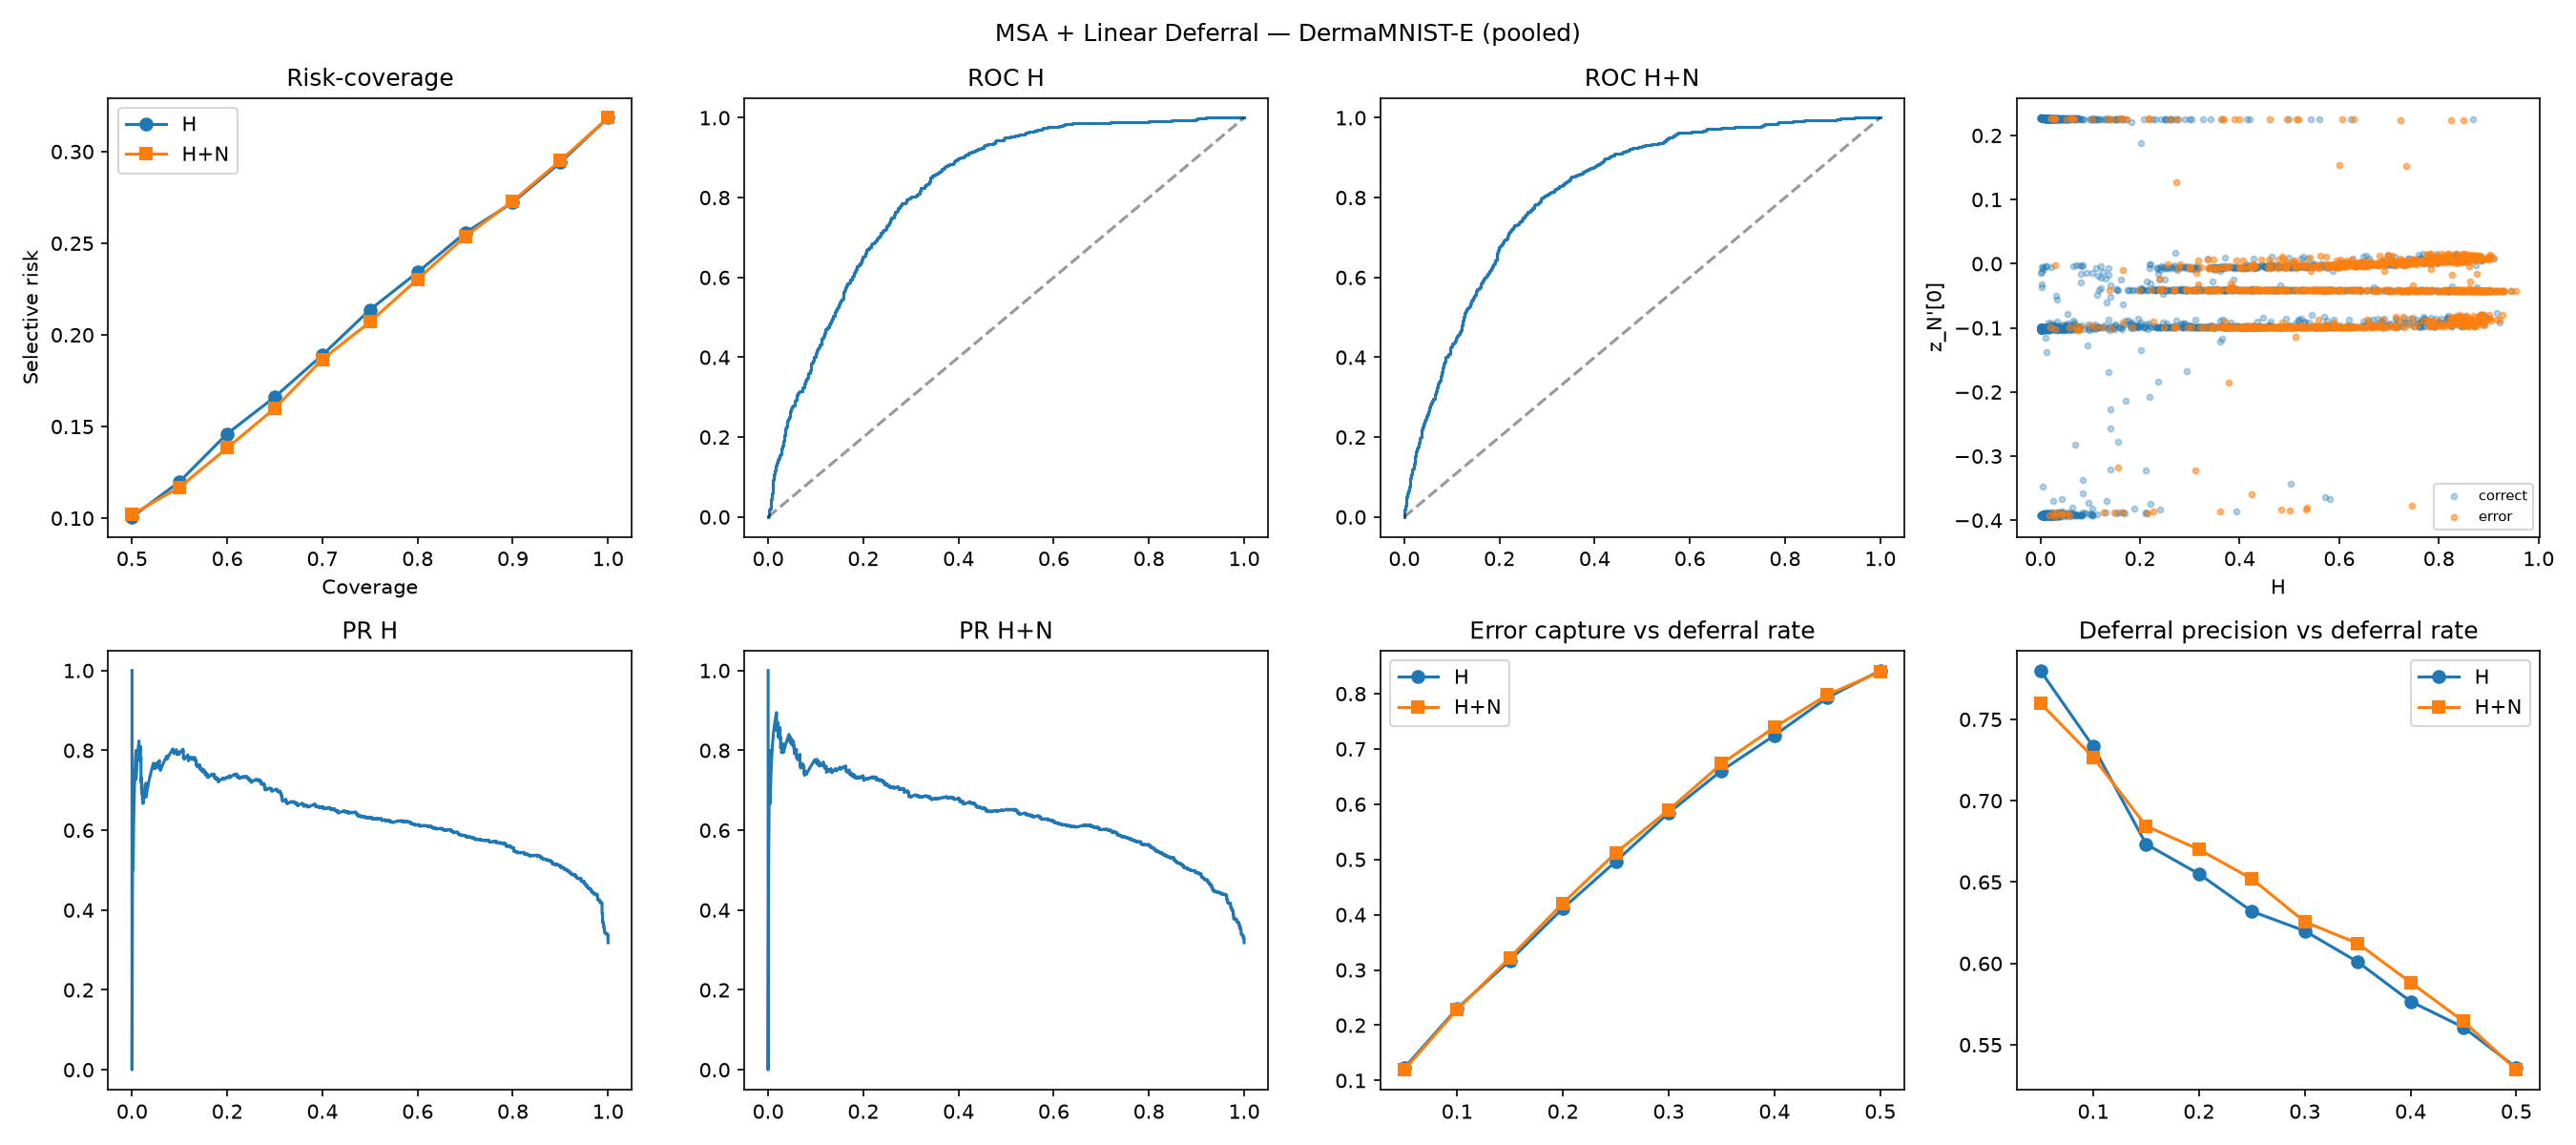

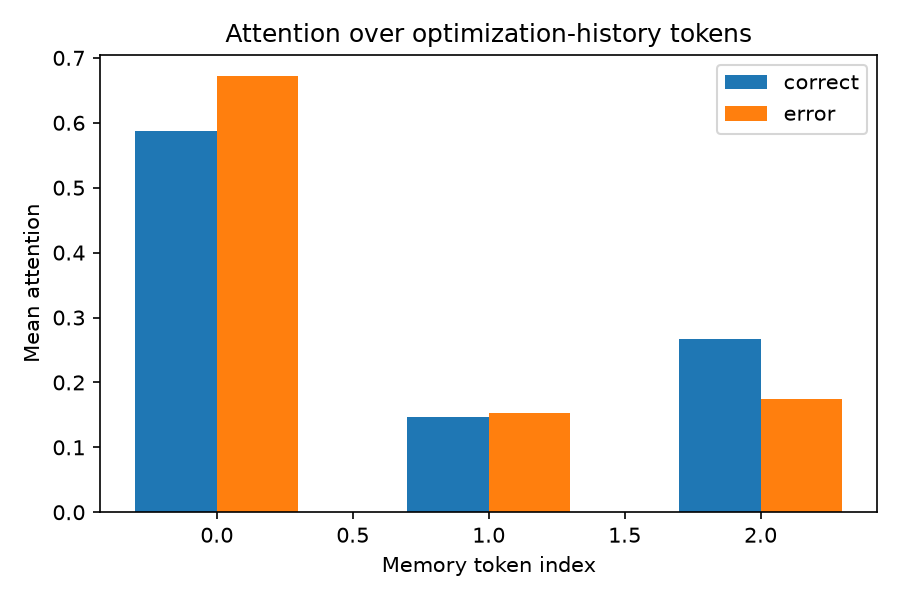

In [5]:
for name in ["msa_linear_deferral_summary.png", "attention_over_memory.png"]:
    p = out / "plots" / name
    if p.exists():
        display(Image(filename=str(p)))

## Pre-registered PASS/FAIL

In [6]:
print_final_verdict(results)

FINAL MSA + LINEAR DEFERRAL — VERDICT: PASS
  Selective risk H:   0.2493
  Selective risk H+N: 0.2423
  Deferral prec H:    0.6499
  Deferral prec H+N:  0.6808
  Error capture H:    0.3518
  Error capture H+N:  0.3707
  delta_risk CI excludes 0: True
